# Exploratory Data Analysis (EDA)

## Import Library

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict

DATASET_PATH = "/content/drive/MyDrive/Dataset PCD/data"
OUTPUT_PATH  = "/content/drive/MyDrive/eda_output"
os.makedirs(OUTPUT_PATH, exist_ok=True)

TARGET_CLASSES = ['Angry', 'Happy', 'Sad']
VALID_EXT      = ['.jpg', '.jpeg', '.png', '.bmp']
COLORS         = {'Angry': '#e05c5c', 'Happy': '#f5c542', 'Sad': '#5b9bd5'}

In [3]:
files = glob.glob(os.path.join(DATASET_PATH, "**", "*"), recursive=True)

filtered = []
for f in files:
    if Path(f).suffix.lower() not in VALID_EXT:
        continue
    for cls in TARGET_CLASSES:
        if cls.lower() in Path(f).parts[-2].lower():
            filtered.append({'path': f, 'label': cls})
            break

df = pd.DataFrame(filtered)

print(f"Total file ditemukan : {len(files)}")
print(f"Setelah filter       : {len(df)} gambar\n")
print("Distribusi kelas:")
vc = df['label'].value_counts()
for cls, n in vc.items():
    print(f"  {cls:>6}: {n} ({n/len(df)*100:.1f}%)")

Total file ditemukan : 268
Setelah filter       : 264 gambar

Distribusi kelas:
   Happy: 100 (37.9%)
   Angry: 86 (32.6%)
     Sad: 78 (29.5%)


## Distribusi kelas

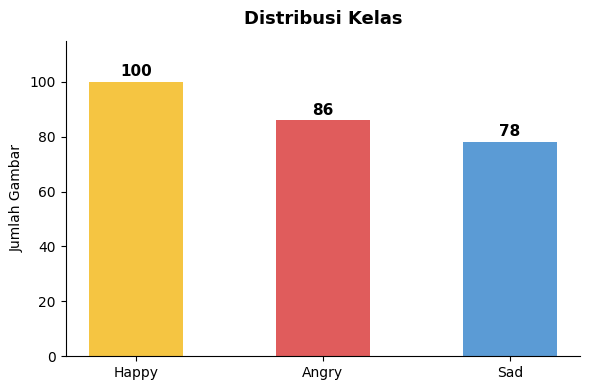

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(vc.index, vc.values,
              color=[COLORS[c] for c in vc.index], width=0.5, edgecolor="none")

for bar, n in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(n), ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Distribusi Kelas", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Jumlah Gambar")
ax.set_ylim(0, vc.max() + 15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "distribusi_kelas.png"), dpi=150)
plt.show()

## Cek ukuran & channel gambar

In [5]:
records = []
unreadable = []

for _, row in df.iterrows():
    img = cv2.imread(row['path'])
    if img is None:
        unreadable.append(row['path'])
        continue
    h, w = img.shape[:2]
    ch   = img.shape[2] if img.ndim == 3 else 1
    records.append({'label': row['label'], 'width': w, 'height': h, 'channels': ch, 'path': row['path']})

df_info = pd.DataFrame(records)

print(f"Gambar tidak bisa dibaca: {len(unreadable)}\n")
print("Statistik ukuran per kelas:")
for cls in TARGET_CLASSES:
    sub = df_info[df_info['label'] == cls]
    print(f"\n  [{cls}]")
    print(f"    width  : {sub['width'].min()} - {sub['width'].max()} px  (rata-rata {sub['width'].mean():.0f})")
    print(f"    height : {sub['height'].min()} - {sub['height'].max()} px  (rata-rata {sub['height'].mean():.0f})")

Gambar tidak bisa dibaca: 0

Statistik ukuran per kelas:

  [Angry]
    width  : 261 - 6016 px  (rata-rata 1073)
    height : 154 - 4016 px  (rata-rata 735)

  [Happy]
    width  : 220 - 5472 px  (rata-rata 1210)
    height : 162 - 3844 px  (rata-rata 806)

  [Sad]
    width  : 291 - 5126 px  (rata-rata 1178)
    height : 168 - 5604 px  (rata-rata 905)


## Scatter plot variasi ukuran

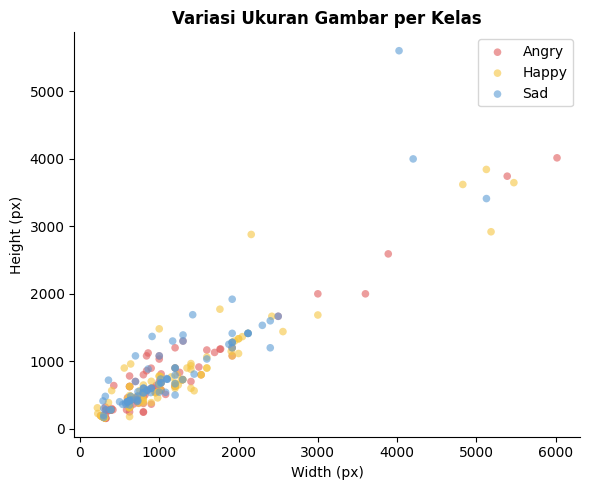

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for cls in TARGET_CLASSES:
    sub = df_info[df_info['label'] == cls]
    ax.scatter(sub['width'], sub['height'], label=cls, alpha=0.6,
               s=30, color=COLORS[cls], edgecolors="none")

ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title("Variasi Ukuran Gambar per Kelas", fontsize=12, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "variasi_ukuran.png"), dpi=150)
plt.show()

## Sample gambar per kelas

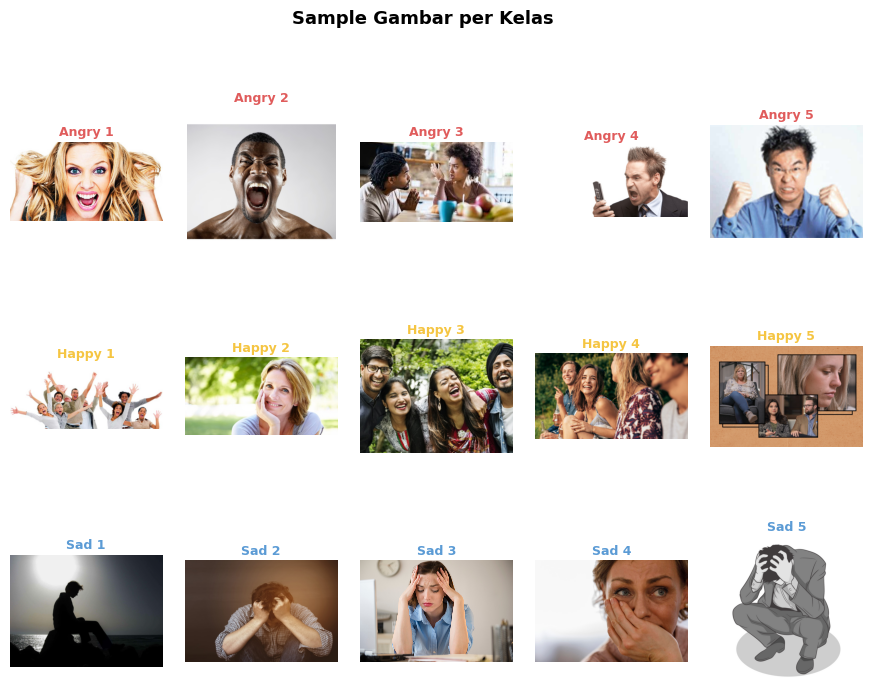

In [7]:
N_SAMPLE = 5
fig = plt.figure(figsize=(N_SAMPLE * 2.2, len(TARGET_CLASSES) * 2.5))
gs  = gridspec.GridSpec(len(TARGET_CLASSES), N_SAMPLE, hspace=0.45, wspace=0.15)

for row_idx, cls in enumerate(TARGET_CLASSES):
    paths  = df_info[df_info['label'] == cls]['path'].values
    sample = np.random.choice(paths, min(N_SAMPLE, len(paths)), replace=False)
    for col, path in enumerate(sample):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax  = fig.add_subplot(gs[row_idx, col])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{cls} {col+1}", fontsize=9, color=COLORS[cls],
                     fontweight="bold", pad=4)
        if col == 0:
            ax.set_ylabel(cls.upper(), fontsize=11, fontweight="bold",
                          color=COLORS[cls], labelpad=8)
            ax.yaxis.set_label_position("left")
            ax.set_yticks([])

fig.suptitle("Sample Gambar per Kelas", fontsize=13, fontweight="bold", y=1.01)
plt.savefig(os.path.join(OUTPUT_PATH, "sample_gambar.png"), dpi=150, bbox_inches="tight")
plt.show()

## Distribusi brightness per kelas

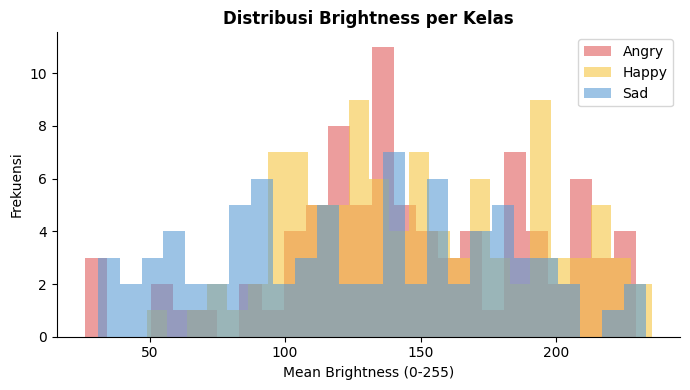

Rata-rata brightness:
   Angry: 146.7  (std 48.0)
   Happy: 149.4  (std 43.6)
     Sad: 125.8  (std 52.2)


In [8]:
brightness_records = []
for _, row in df_info.iterrows():
    gray = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
    if gray is None:
        continue
    brightness_records.append({'label': row['label'], 'brightness': np.mean(gray)})

df_bright = pd.DataFrame(brightness_records)

fig, ax = plt.subplots(figsize=(7, 4))
for cls in TARGET_CLASSES:
    vals = df_bright[df_bright['label'] == cls]['brightness']
    ax.hist(vals, bins=25, alpha=0.6, label=cls, color=COLORS[cls], edgecolor="none")

ax.set_xlabel("Mean Brightness (0-255)")
ax.set_ylabel("Frekuensi")
ax.set_title("Distribusi Brightness per Kelas", fontsize=12, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, "distribusi_brightness.png"), dpi=150)
plt.show()

print("Rata-rata brightness:")
for cls in TARGET_CLASSES:
    vals = df_bright[df_bright['label'] == cls]['brightness']
    print(f"  {cls:>6}: {vals.mean():.1f}  (std {vals.std():.1f})")

## Deteksi gambar bermasalah

In [9]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
masalah = []

for _, row in df_info.iterrows():
    gray = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
    if gray is None:
        masalah.append({'path': row['path'], 'label': row['label'], 'isu': 'tidak bisa dibaca'})
        continue

    mean_bright = np.mean(gray)
    if mean_bright < 20:
        masalah.append({'path': row['path'], 'label': row['label'], 'isu': 'terlalu gelap'})
    elif mean_bright > 240:
        masalah.append({'path': row['path'], 'label': row['label'], 'isu': 'terlalu terang'})


df_masalah = pd.DataFrame(masalah)
print(f"Total gambar bermasalah: {len(df_masalah)} dari {len(df_info)}")
if len(df_masalah):
    print("\nBreakdown per isu:")
    print(df_masalah['isu'].value_counts().to_string())
    print("\nBreakdown per kelas:")
    print(df_masalah['label'].value_counts().to_string())
    df_masalah.to_csv(os.path.join(OUTPUT_PATH, "gambar_bermasalah.csv"), index=False)

Total gambar bermasalah: 0 dari 264


# Split data

In [10]:
from sklearn.model_selection import train_test_split

df_split = df_info[['path', 'label']].copy()

X_trainval, X_test = train_test_split(
    df_split,
    test_size=0.15,
    stratify=df_split['label'],
    random_state=42
)

X_trainval = X_trainval.reset_index(drop=True)
X_test     = X_test.reset_index(drop=True)

print(f"Train+Val : {len(X_trainval)}")
print(f"Test      : {len(X_test)}")
print("\nDistribusi train+val:")
for cls in TARGET_CLASSES:
    n = (X_trainval['label'] == cls).sum()
    print(f"  {cls:>6}: {n} ({n/len(X_trainval)*100:.1f}%)")

print("\nDistribusi test:")
for cls in TARGET_CLASSES:
    n = (X_test['label'] == cls).sum()
    print(f"  {cls:>6}: {n} ({n/len(X_test)*100:.1f}%)")

Train+Val : 224
Test      : 40

Distribusi train+val:
   Angry: 73 (32.6%)
   Happy: 85 (37.9%)
     Sad: 66 (29.5%)

Distribusi test:
   Angry: 13 (32.5%)
   Happy: 15 (37.5%)
     Sad: 12 (30.0%)


## augmentasi (data train saja)

In [11]:
import cv2
import numpy as np
from sklearn.model_selection import StratifiedKFold

def augment_image(img):
    h, w = img.shape[:2]
    results = [img]

    results.append(cv2.flip(img, 1))

    for angle in [-10, 10]:
        M   = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        rot = cv2.warpAffine(img, M, (w, h))
        results.append(rot)

    for factor in [0.8, 1.2]:
        bright = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
        results.append(bright)

    return results


def load_images(df_subset):
    images, labels = [], []
    for _, row in df_subset.iterrows():
        img = cv2.imread(row['path'])
        if img is None:
            continue
        img = cv2.resize(img, (64, 64))
        images.append(img)
        labels.append(row['label'])
    return images, labels


def apply_augmentation(images, labels):
    aug_images, aug_labels = [], []
    for img, label in zip(images, labels):
        for aug in augment_image(img):
            aug_images.append(aug)
            aug_labels.append(label)
    return aug_images, aug_labels


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_summary = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval, X_trainval['label']), start=1):
    df_train_fold = X_trainval.iloc[train_idx].reset_index(drop=True)
    df_val_fold   = X_trainval.iloc[val_idx].reset_index(drop=True)

    train_images, train_labels = load_images(df_train_fold)
    val_images,   val_labels   = load_images(df_val_fold)

    # augmentasi hanya pada train fold
    train_images, train_labels = apply_augmentation(train_images, train_labels)

    fold_summary.append({
        'fold'      : fold,
        'train_asli': len(df_train_fold),
        'train_aug' : len(train_images),
        'val'       : len(val_images)
    })

    print(f"Fold {fold} | train asli: {len(df_train_fold)} → setelah aug: {len(train_images)} | val: {len(val_images)}")

print(f"\nRata-rata train setelah aug : {np.mean([f['train_aug'] for f in fold_summary]):.0f}")
print(f"Rata-rata val (murni)       : {np.mean([f['val'] for f in fold_summary]):.0f}")

Fold 1 | train asli: 179 → setelah aug: 1074 | val: 45
Fold 2 | train asli: 179 → setelah aug: 1074 | val: 45
Fold 3 | train asli: 179 → setelah aug: 1074 | val: 45
Fold 4 | train asli: 179 → setelah aug: 1074 | val: 45
Fold 5 | train asli: 180 → setelah aug: 1080 | val: 44

Rata-rata train setelah aug : 1075
Rata-rata val (murni)       : 45


## Ekstraksi Fitur (HOG + LBP + Color Histogram)

In [12]:
from skimage.feature import hog, local_binary_pattern

def normalize_lighting(img):
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l       = clahe.apply(l)
    lab     = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def extract_features(images):
    features = []
    for img in images:
        img        = normalize_lighting(img)
        img_resized = cv2.resize(img, (64, 64))

        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

        # HOG
        hog_feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        # LBP
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)

        # Color Histogram (RGB)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        color_hist = []
        for ch in range(3):
            hist, _ = np.histogram(img_rgb[:, :, ch], bins=64, range=(0, 256), density=True)
            color_hist.append(hist)
        color_hist = np.concatenate(color_hist)

        combined = np.hstack([hog_feat, lbp_hist, color_hist])
        features.append(combined)

    return np.array(features)

In [13]:
from sklearn.preprocessing import StandardScaler

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_data = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval, X_trainval['label']), start=1):
    df_train_fold = X_trainval.iloc[train_idx].reset_index(drop=True)
    df_val_fold   = X_trainval.iloc[val_idx].reset_index(drop=True)

    train_images, train_labels = load_images(df_train_fold)
    val_images,   val_labels   = load_images(df_val_fold)

    train_images, train_labels = apply_augmentation(train_images, train_labels)

    X_train = extract_features(train_images)
    X_val   = extract_features(val_images)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)

    fold_data.append({
        'fold'        : fold,
        'X_train'     : X_train,
        'y_train'     : train_labels,
        'X_val'       : X_val,
        'y_val'       : val_labels,
        'scaler'      : scaler,
        'n_features'  : X_train.shape[1]
    })

    print(f"Fold {fold} | train: {X_train.shape} | val: {X_val.shape}")

print(f"\nTotal fitur per gambar: {fold_data[0]['n_features']}")

Fold 1 | train: (1074, 1966) | val: (45, 1966)
Fold 2 | train: (1074, 1966) | val: (45, 1966)
Fold 3 | train: (1074, 1966) | val: (45, 1966)
Fold 4 | train: (1074, 1966) | val: (45, 1966)
Fold 5 | train: (1080, 1966) | val: (44, 1966)

Total fitur per gambar: 1966


## Menghitung class weight

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# ambil label dari semua fold train (fold 1 cukup representatif, atau gabungkan semua)
all_train_labels = []
for fd in fold_data:
    all_train_labels.extend(fd['y_train'])

classes = sorted(set(all_train_labels))

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(classes),
    y=all_train_labels
)

class_weight = dict(zip(classes, weights))
print("Class Weight:")
for cls, w in class_weight.items():
    print(f"  {cls:>6}: {w:.4f}")

Class Weight:
   Angry: 1.0228
   Happy: 0.8784
     Sad: 1.1313


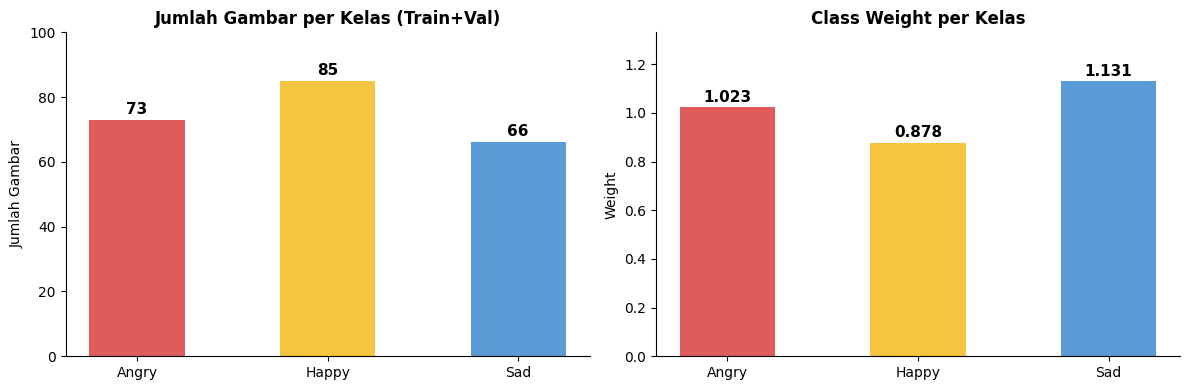

In [15]:
# hitung frekuensi asli untuk konteks visualisasi
from collections import Counter

label_counts = Counter(X_trainval['label'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    [c for c in classes],
    [label_counts[c] for c in classes],
    color=[COLORS[c] for c in classes],
    width=0.5,
    edgecolor='none'
)
for bar, cls in zip(bars, classes):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(label_counts[cls]),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Jumlah Gambar per Kelas (Train+Val)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_ylim(0, max(label_counts.values()) + 15)
axes[0].spines[['top', 'right']].set_visible(False)

bars2 = axes[1].bar(
    classes,
    [class_weight[c] for c in classes],
    color=[COLORS[c] for c in classes],
    width=0.5,
    edgecolor='none'
)
for bar, cls in zip(bars2, classes):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{class_weight[cls]:.3f}",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_title('Class Weight per Kelas', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].set_ylim(0, max(class_weight.values()) + 0.2)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'class_weight.png'), dpi=150)
plt.show()

# K-Fold CV Baseline Model

In [16]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score
import time

results = {}

## Support Vector Machine (SVM)

In [17]:
name   = 'SVM'
res    = {'f1_per_fold': [], 'waktu_per_fold': [], 'models': []}

for fd in fold_data:
    model = SVC(class_weight=class_weight, random_state=42)

    start = time.time()
    model.fit(fd['X_train'], fd['y_train'])
    elapsed = time.time() - start

    f1 = f1_score(fd['y_val'], model.predict(fd['X_val']), average='weighted')

    res['f1_per_fold'].append(f1)
    res['waktu_per_fold'].append(elapsed)
    res['models'].append(model)

results[name] = res
print(f"[SVM] Mean F1: {np.mean(res['f1_per_fold']):.4f}  Std: {np.std(res['f1_per_fold']):.4f}  Waktu: {np.mean(res['waktu_per_fold']):.2f}s")

[SVM] Mean F1: 0.5450  Std: 0.0536  Waktu: 1.28s


## Random Forest

In [18]:
name = 'Random Forest'
res  = {'f1_per_fold': [], 'waktu_per_fold': [], 'models': []}

for fd in fold_data:
    model = RandomForestClassifier(class_weight=class_weight, random_state=42)

    start = time.time()
    model.fit(fd['X_train'], fd['y_train'])
    elapsed = time.time() - start

    f1 = f1_score(fd['y_val'], model.predict(fd['X_val']), average='weighted')

    res['f1_per_fold'].append(f1)
    res['waktu_per_fold'].append(elapsed)
    res['models'].append(model)

results[name] = res
print(f"[Random Forest] Mean F1: {np.mean(res['f1_per_fold']):.4f}  Std: {np.std(res['f1_per_fold']):.4f}  Waktu: {np.mean(res['waktu_per_fold']):.2f}s")

[Random Forest] Mean F1: 0.5624  Std: 0.0720  Waktu: 5.28s


## k-Nearest Neighbors (k-NN)

In [19]:
name = 'k-NN'
res  = {'f1_per_fold': [], 'waktu_per_fold': [], 'models': []}

for fd in fold_data:
    model = KNeighborsClassifier()

    start = time.time()
    model.fit(fd['X_train'], fd['y_train'])
    elapsed = time.time() - start

    f1 = f1_score(fd['y_val'], model.predict(fd['X_val']), average='weighted')

    res['f1_per_fold'].append(f1)
    res['waktu_per_fold'].append(elapsed)
    res['models'].append(model)

results[name] = res
print(f"[k-NN] Mean F1: {np.mean(res['f1_per_fold']):.4f}  Std: {np.std(res['f1_per_fold']):.4f}  Waktu: {np.mean(res['waktu_per_fold']):.2f}s")

[k-NN] Mean F1: 0.4617  Std: 0.0547  Waktu: 0.00s


## Naive Bayes (Gaussian)

In [20]:
name = 'Naive Bayes'
res  = {'f1_per_fold': [], 'waktu_per_fold': [], 'models': []}

for fd in fold_data:
    model = GaussianNB()

    start = time.time()
    model.fit(fd['X_train'], fd['y_train'])
    elapsed = time.time() - start

    f1 = f1_score(fd['y_val'], model.predict(fd['X_val']), average='weighted')

    res['f1_per_fold'].append(f1)
    res['waktu_per_fold'].append(elapsed)
    res['models'].append(model)

results[name] = res
print(f"[Naive Bayes] Mean F1: {np.mean(res['f1_per_fold']):.4f}  Std: {np.std(res['f1_per_fold']):.4f}  Waktu: {np.mean(res['waktu_per_fold']):.2f}s")

[Naive Bayes] Mean F1: 0.4192  Std: 0.0433  Waktu: 0.03s


## Multi-Layer Perceptron (MLP)

In [21]:
from sklearn.neural_network import MLPClassifier

name = 'MLP'
res  = {'f1_per_fold': [], 'waktu_per_fold': [], 'models': []}

for fd in fold_data:
    model = MLPClassifier(random_state=42, max_iter=300)

    start = time.time()
    model.fit(fd['X_train'], fd['y_train'])
    elapsed = time.time() - start

    f1 = f1_score(fd['y_val'], model.predict(fd['X_val']), average='weighted')

    res['f1_per_fold'].append(f1)
    res['waktu_per_fold'].append(elapsed)
    res['models'].append(model)

results[name] = res
print(f"[MLP] Mean F1: {np.mean(res['f1_per_fold']):.4f}  Std: {np.std(res['f1_per_fold']):.4f}  Waktu: {np.mean(res['waktu_per_fold']):.2f}s")

[MLP] Mean F1: 0.5191  Std: 0.0807  Waktu: 3.64s


## Perbandingan seluruh model baseline

In [22]:
model_names = list(results.keys())

print(f"{'Model':<16} {'F1 per Fold':<45} {'Mean F1':>8}  {'Std':>6}  {'Waktu (s)':>10}")
print("-" * 90)
for name, res in results.items():
    f1_list  = res['f1_per_fold']
    fold_str = '  '.join([f"{v:.4f}" for v in f1_list])
    print(f"{name:<16} {fold_str:<45} {np.mean(f1_list):>8.4f}  {np.std(f1_list):>6.4f}  {np.mean(res['waktu_per_fold']):>9.2f}s")

best_model_name = max(results, key=lambda n: np.mean(results[n]['f1_per_fold']))
best_fold_idx   = int(np.argmax(results[best_model_name]['f1_per_fold']))
best_model      = results[best_model_name]['models'][best_fold_idx]
best_scaler     = fold_data[best_fold_idx]['scaler']

print(f"\nModel terbaik : {best_model_name}")
print(f"Fold terbaik  : {best_fold_idx + 1}")
print(f"F1-weighted   : {results[best_model_name]['f1_per_fold'][best_fold_idx]:.4f}")

Model            F1 per Fold                                    Mean F1     Std   Waktu (s)
------------------------------------------------------------------------------------------
SVM              0.6266  0.5419  0.4663  0.5724  0.5177          0.5450  0.0536       1.28s
Random Forest    0.6807  0.5241  0.5058  0.6097  0.4918          0.5624  0.0720       5.28s
k-NN             0.4906  0.4288  0.4253  0.4081  0.5559          0.4617  0.0547       0.00s
Naive Bayes      0.4667  0.4118  0.4446  0.3401  0.4326          0.4192  0.0433       0.03s
MLP              0.5993  0.5210  0.4581  0.6140  0.4031          0.5191  0.0807       3.64s

Model terbaik : Random Forest
Fold terbaik  : 1
F1-weighted   : 0.6807


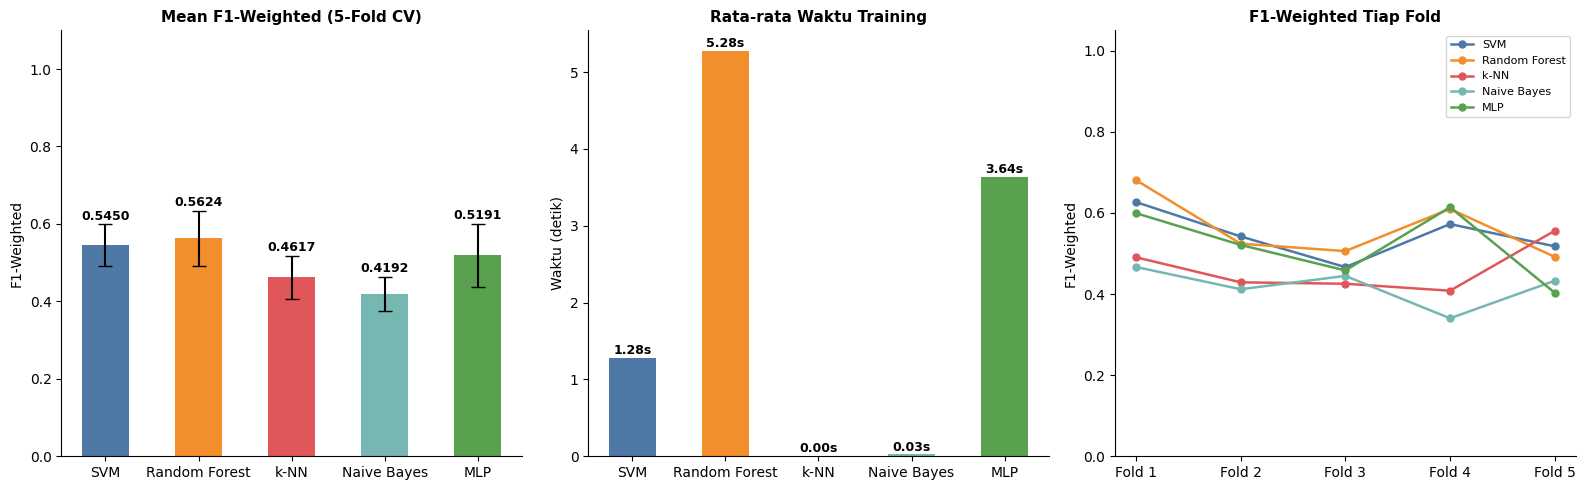

In [23]:
bar_colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

mean_f1    = [np.mean(results[n]['f1_per_fold'])    for n in model_names]
std_f1     = [np.std(results[n]['f1_per_fold'])     for n in model_names]
mean_waktu = [np.mean(results[n]['waktu_per_fold']) for n in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars = axes[0].bar(model_names, mean_f1, yerr=std_f1, capsize=5,
                   color=bar_colors, width=0.5, edgecolor='none',
                   error_kw={'elinewidth': 1.5})
for bar, m, s in zip(bars, mean_f1, std_f1):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + s + 0.005,
                 f"{m:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Mean F1-Weighted (5-Fold CV)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('F1-Weighted')
axes[0].set_ylim(0, 1.1)
axes[0].spines[['top', 'right']].set_visible(False)

bars2 = axes[1].bar(model_names, mean_waktu, color=bar_colors, width=0.5, edgecolor='none')
for bar, w in zip(bars2, mean_waktu):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{w:.2f}s", ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Rata-rata Waktu Training', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Waktu (detik)')
axes[1].spines[['top', 'right']].set_visible(False)

x = np.arange(1, 6)
for name, color in zip(model_names, bar_colors):
    axes[2].plot(x, results[name]['f1_per_fold'], marker='o', label=name,
                 color=color, linewidth=1.8, markersize=5)
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"Fold {i}" for i in x])
axes[2].set_ylabel('F1-Weighted')
axes[2].set_title('F1-Weighted Tiap Fold', fontsize=11, fontweight='bold')
axes[2].set_ylim(0, 1.05)
axes[2].legend(fontsize=8)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'baseline_kfold.png'), dpi=150)
plt.show()

## Tuning (GridSearchCV)

In [24]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

kf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_tune = np.vstack([fd['X_train'] for fd in fold_data])
y_tune = []
for fd in fold_data:
    y_tune.extend(fd['y_train'])

print(f"Tuning model : {best_model_name}")
print(f"Data tuning  : {X_tune.shape}")

Tuning model : Random Forest
Data tuning  : (5376, 1966)


In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

kf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# augmentasi manual per fold untuk menghindari leakage
X_tune_list, y_tune_list = [], []

for train_idx, _ in kf_tune.split(X_trainval, X_trainval['label']):
    df_fold = X_trainval.iloc[train_idx].reset_index(drop=True)
    imgs, lbls = load_images(df_fold)
    imgs, lbls = apply_augmentation(imgs, lbls)
    feats = extract_features(imgs)
    X_tune_list.append(feats)
    y_tune_list.extend(lbls)

# gunakan fold pertama sebagai representasi data tuning
X_tune_aug = X_tune_list[0]
y_tune_aug = y_tune_list[:len(X_tune_aug)]

print(f"Data tuning setelah augmentasi: {X_tune_aug.shape}")

Data tuning setelah augmentasi: (1074, 1966)


## Menentukan parameter grid sesuai model terbaik

In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'C'     : [1, 10, 100],
    'gamma' : ['scale', 0.001, 0.01],
    'kernel': ['rbf']
}

base = SVC(class_weight=class_weight, probability=True, random_state=42)

grid = RandomizedSearchCV(
    base, param_grid,
    n_iter=9,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted',
    random_state=42,
    n_jobs=1,
    verbose=1
)
grid.fit(X_tune_aug, y_tune_aug)

tuned_model = grid.best_estimator_
baseline_f1 = np.mean(results[best_model_name]['f1_per_fold'])

print(f"\nParameter terbaik : {grid.best_params_}")
print(f"F1 sebelum tuning : {baseline_f1:.4f}")
print(f"F1 setelah tuning : {grid.best_score_:.4f}")
print(f"Peningkatan F1    : {grid.best_score_ - baseline_f1:+.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Parameter terbaik : {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
F1 sebelum tuning : 0.5624
F1 setelah tuning : 0.8095
Peningkatan F1    : +0.2471


# Evaluasi model

In [27]:
# test set diambil dari X_test yang dikunci sejak awal (15%)
test_images, test_labels = load_images(X_test)
X_test_feat = extract_features(test_images)

print(f"Jumlah test  : {len(test_images)}")
print(f"Shape fitur  : {X_test_feat.shape}")

Jumlah test  : 40
Shape fitur  : (40, 1966)


## Prediksi & laporan klasifikasi

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

y_pred = tuned_model.predict(X_test_feat)

print("Laporan Klasifikasi")
print(classification_report(test_labels, y_pred, target_names=TARGET_CLASSES))

Laporan Klasifikasi
              precision    recall  f1-score   support

       Angry       0.53      0.62      0.57        13
       Happy       0.60      0.80      0.69        15
         Sad       0.80      0.33      0.47        12

    accuracy                           0.60        40
   macro avg       0.64      0.58      0.58        40
weighted avg       0.64      0.60      0.58        40



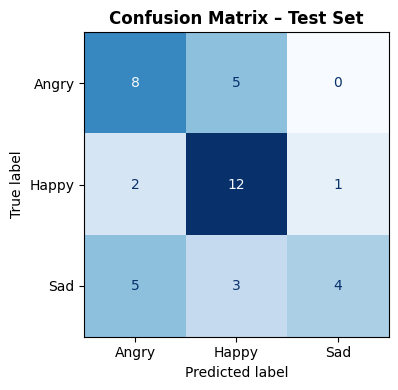

In [29]:
cm   = confusion_matrix(test_labels, y_pred, labels=TARGET_CLASSES)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_CLASSES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix – Test Set", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

In [30]:
acc    = accuracy_score(test_labels, y_pred)
f1_w   = f1_score(test_labels, y_pred, average='weighted')
f1_per = f1_score(test_labels, y_pred, average=None, labels=TARGET_CLASSES)

print(f"Akurasi     : {acc:.4f}  ({acc*100:.1f}%)")
print(f"F1 Weighted : {f1_w:.4f}")
print()
print("F1 per kelas:")
for cls, f1 in zip(TARGET_CLASSES, f1_per):
    print(f"  {cls:>6} : {f1:.4f}")

Akurasi     : 0.6000  (60.0%)
F1 Weighted : 0.5840

F1 per kelas:
   Angry : 0.5714
   Happy : 0.6857
     Sad : 0.4706


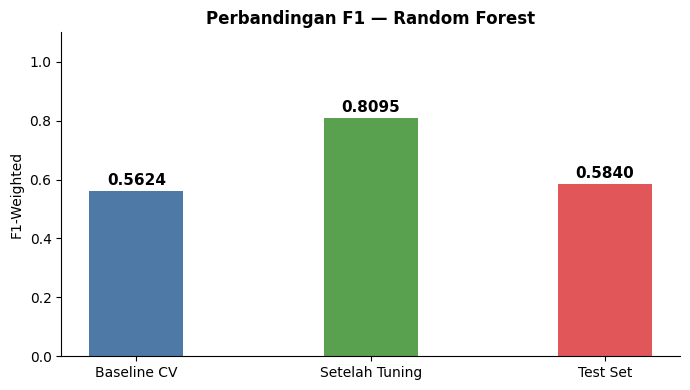

In [31]:
labels_bar = ['Baseline CV', 'Setelah Tuning', 'Test Set']
values_bar = [
    np.mean(results[best_model_name]['f1_per_fold']),
    grid.best_score_,
    f1_w
]
colors_bar = ['#4e79a7', '#59a14f', '#e15759']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels_bar, values_bar, color=colors_bar, width=0.4, edgecolor='none')

for bar, val in zip(bars, values_bar):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('F1-Weighted')
ax.set_ylim(0, 1.1)
ax.set_title(f'Perbandingan F1 — {best_model_name}', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'evaluasi_final.png'), dpi=150)
plt.show()

# Uji foto/emoji pribadi

In [32]:
FOTO_PATH = "/content/drive/MyDrive/Foto_Saya"

foto_files = sorted([
    f for f in glob.glob(os.path.join(FOTO_PATH, "*"))
    if Path(f).suffix.lower() in VALID_EXT
])

print(f"Total foto ditemukan: {len(foto_files)}")
for f in foto_files:
    print(f"  {Path(f).name}")

Total foto ditemukan: 10
  CD63FCF3-F588-478C-9B32-218E31610F67.jpg
  IMG_9457.jpg
  IMG_9462.jpg
  download (1).jpg
  download (2).jpg
  download (3).jpg
  download (4).jpg
  download (5).jpg
  download.jpg
  png-clipart-sadness-child-sad-s-hand-human-thumbnail.png


## Prediksi semua foto sekaligus

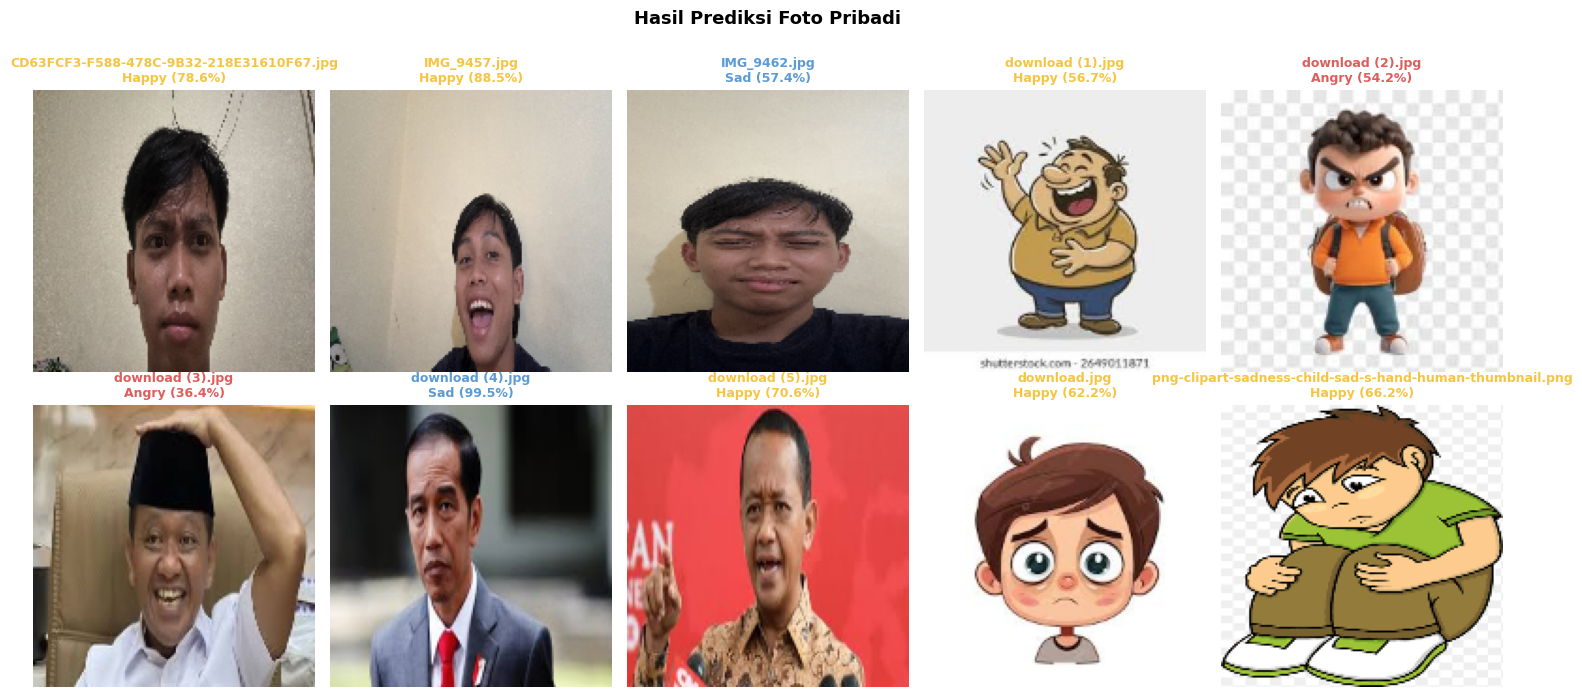

In [34]:
n      = len(foto_files)
ncols  = 5
nrows  = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.5))
axes      = axes.flatten()

prediksi_log = []

for i, path in enumerate(foto_files):
    img = cv2.imread(path)

    if img is None:
        axes[i].set_title("Tidak bisa dibaca", fontsize=9, color='red')
        axes[i].axis('off')
        continue

    feat  = extract_features([img])
    pred  = tuned_model.predict(feat)[0]
    proba = tuned_model.predict_proba(feat)[0]
    conf  = max(proba)

    prediksi_log.append({
        'file'      : Path(path).name,
        'prediksi'  : pred,
        'confidence': conf,
        'Angry'     : proba[TARGET_CLASSES.index('Angry')],
        'Happy'     : proba[TARGET_CLASSES.index('Happy')],
        'Sad'       : proba[TARGET_CLASSES.index('Sad')]
    })

    img_rgb = cv2.cvtColor(cv2.resize(img, (150, 150)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(
        f"{Path(path).name}\n{pred} ({conf*100:.1f}%)",
        fontsize=9, fontweight='bold',
        color=COLORS.get(pred, 'black')
    )
    axes[i].axis('off')

# sembunyikan axes kosong jika foto < grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Hasil Prediksi Foto Pribadi", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'prediksi_foto.png'), dpi=150, bbox_inches='tight')
plt.show()